In [2]:
import numpy as np
from matplotlib import pyplot as plt 
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

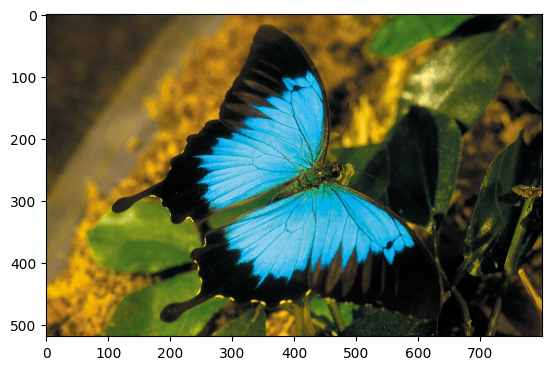

In [3]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')/255.0
plt.imshow(im[:,:,[2,1,0]])
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [25]:
def kmeans(im, iters=10, K=3, plot=False):
    
    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)
    
       
    # Convert image into an Nx3 vector of pixels
    d, w, c = im.shape
    pixels = im.reshape(-1, c)
    
    # Select K random colour centroids
    centroids = pixels[np.random.choice(pixels.shape[0], K, replace=False)]
    
    for j in range(iters):
        
        # Assign pixels to clusters
        cluster_indices = np.argmin(np.linalg.norm(pixels[:, np.newaxis] - centroids, axis=2), axis=1)
        
        # Update centroids with a safety check for empty clusters
        new_centroids = []
        for k in range(K):
            mask = (cluster_indices == k)
            if np.any(mask):
                new_centroids.append(pixels[mask].mean(axis=0))
            else:
                # If a cluster is empty, re-pick a random pixel to "re-seed" it
                new_centroids.append(pixels[np.random.randint(0, len(pixels))])
        centroids = np.array(new_centroids)
        
        # Store the current loss
        loss = np.sum((pixels - centroids[cluster_indices])**2)
        
        # Convert cluster indices to an image
        cluster_idx_image = cluster_indices.reshape(d, w)
        
        # Create a quantised image using the clustering
        quantised_image = centroids[cluster_indices].reshape(d, w, c)
        
        # You may want to visualise the current progress of kmeans for debugging purposes
        if plot:
            plt.subplot(1,2,1)
            plt.imshow(cluster_idx_image)
            plt.subplot(1,2,2)
            plt.imshow(quantised_image)
            plt.show()
        
    # Convert cluster indices to an image
    cluster_idx_image = cluster_indices.reshape(d, w)
    

    # Create a quantised image using the clustering
    quantised_pixels = centroids[cluster_indices]

    quantised_image = quantised_pixels.reshape(d, w, c)

    # Convert back to uint8
    quantised_image = (quantised_pixels.reshape(d, w, c) * 255).astype(np.uint8)

    quantised_pixels = centroids[cluster_indices] 
    print(f"Centroids Max: {centroids.max()}")
    return loss, cluster_idx_image, quantised_image 


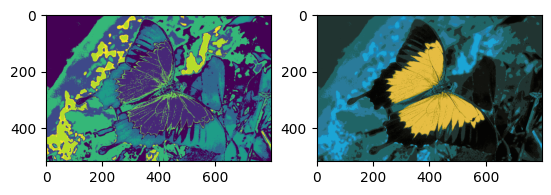

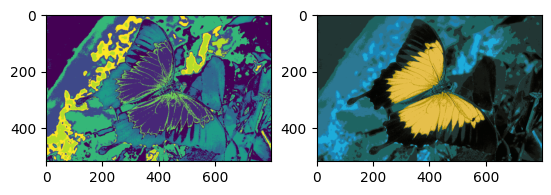

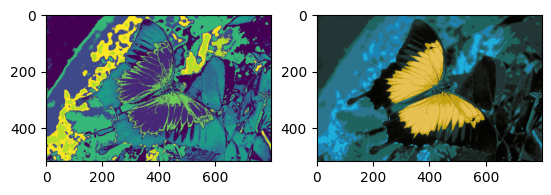

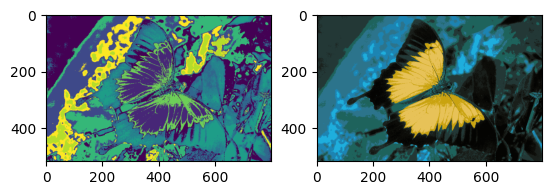

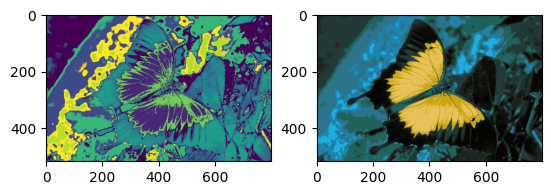

In [21]:
# Test your function using the image provided
loss, cluster_idx_image, quantised_image = kmeans(im, iters=5, K=10, plot=True)

Centroids Max: 0.8582557526090139
Min: 28, Max: 218, Dtype: uint8
Centroids Max: 0.8697030974009489
Min: 12, Max: 221, Dtype: uint8
Centroids Max: 0.9051136836386111
Min: 2, Max: 230, Dtype: uint8
Centroids Max: 0.9053446020239306
Min: 1, Max: 230, Dtype: uint8
Centroids Max: 0.9055080828029739
Min: 1, Max: 230, Dtype: uint8


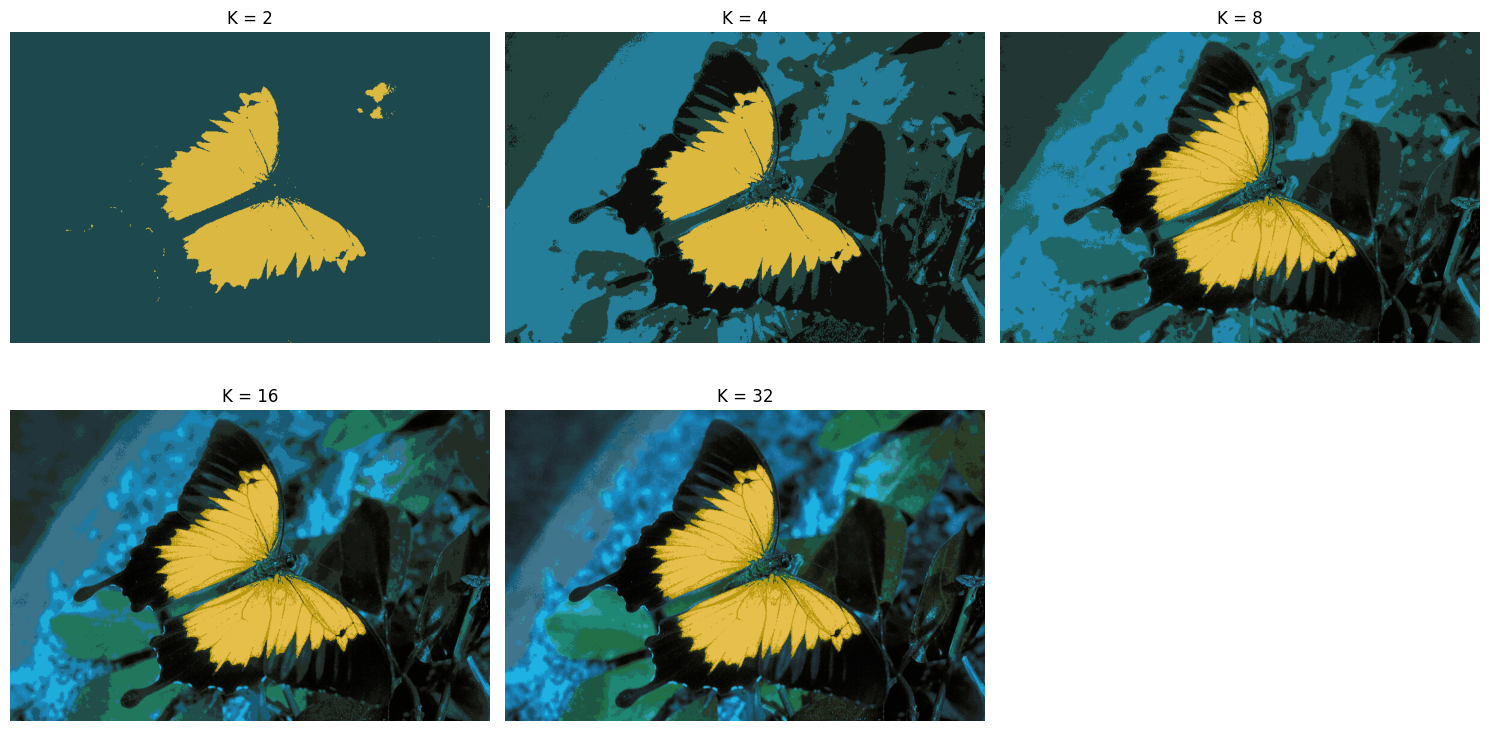

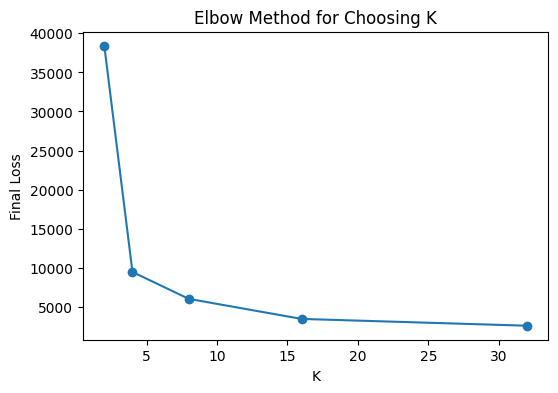

In [ ]:
# Select an appropriate value for K and use visualisations to show how you did this
Ks = [2, 4, 8, 16, 32]

final_losses = []

plt.figure(figsize=(15,8))

for i, K in enumerate(Ks):

    loss, cluster_img, quant_img = kmeans(im, iters=2, K=K)

    final_losses.append(loss)

    # print(f"Min: {quant_img.min()}, Max: {quant_img.max()}, Dtype: {quant_img.dtype}")

    plt.subplot(2,3,i+1)
    plt.imshow(quant_img)
    plt.title(f"K = {K}")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))

plt.plot(Ks, final_losses, marker='o')

plt.xlabel("K")
plt.ylabel("Final Loss")
plt.title("Elbow Method for Choosing K")

plt.show()


Looking at the graph we can see the elbow occurring at K=8, suggesting that this is the point of diminishing returns, where adding more clusters provides only marginal improvements in image fidelity relative to the increased computational cost.

### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

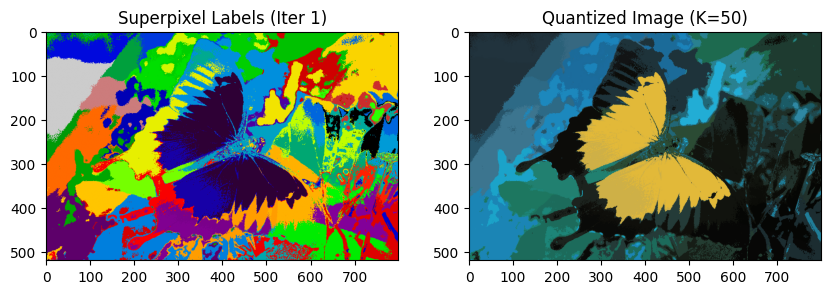

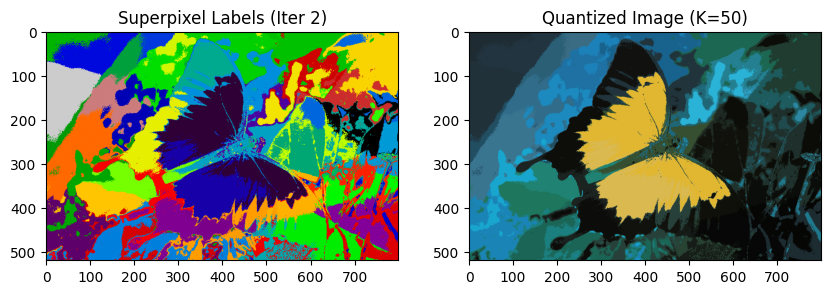

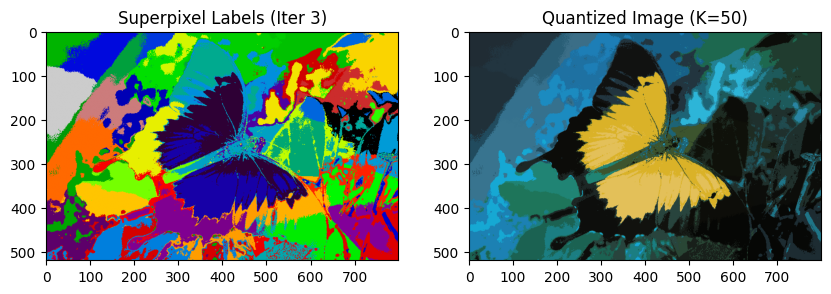

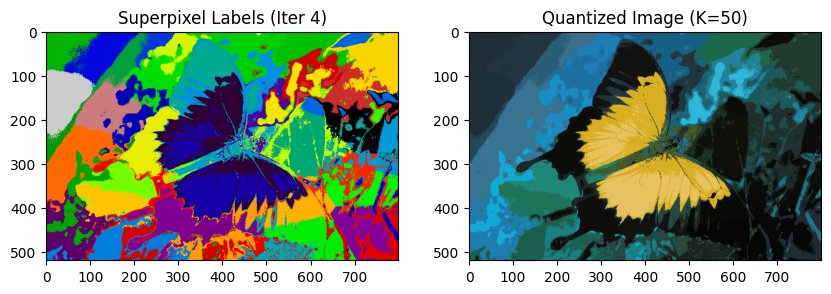

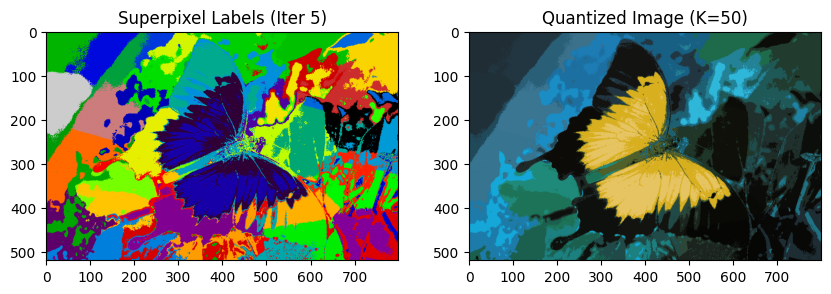

In [41]:
# Use your kmeans function to cluster based on colour and location
def kmeans_superpixels(im, iters=10, K=3, plot=False, spatial_scaling=2.5):
    seed = 42
    np.random.seed(seed)
    
    d, w, c = im.shape
    
    # Create a grid of coordinates (x, y)
    x, y = np.meshgrid(np.arange(w), np.arange(d))
    
    # Normalize coordinates to [0, 1] to match color range
    x_norm = (x / (w - 1)) * spatial_scaling
    y_norm = (y / (d - 1)) * spatial_scaling
    
    # Stack color and spatial features: [R, G, B, X, Y]
    # Shape of features will be (N, 5)
    features = np.dstack((im, x_norm, y_norm)).reshape(-1, 5)
    
    # Select K random feature centroids
    centroids = features[np.random.choice(features.shape[0], K, replace=False)]
    
    for j in range(iters):
        # Assign pixels to clusters based on Color + Position
        distances = np.linalg.norm(features[:, np.newaxis] - centroids, axis=2)
        cluster_indices = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = []
        for k in range(K):
            mask = (cluster_indices == k)
            if np.any(mask):
                new_centroids.append(features[mask].mean(axis=0))
            else:
                new_centroids.append(features[np.random.randint(0, len(features))])
        centroids = np.array(new_centroids)
        
        # Calculate loss
        loss = np.sum((features - centroids[cluster_indices])**2)

        # You may want to visualise the current progress of kmeans for debugging purposes
        if plot:
            # We only use the first 3 dimensions (RGB) for the display image
            rgb_centroids = centroids[:, :3]
            quantised_pixels = rgb_centroids[cluster_indices]
            
            # Reshape for display (scaling back to 0-255)
            # Use a local variable so we don't mess with the loop variables
            current_quant = (quantised_pixels.reshape(d, w, 3) * 255).astype(np.uint8)
            current_clusters = cluster_indices.reshape(d, w)
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(current_clusters, cmap='nipy_spectral')
            plt.title(f"Superpixel Labels (Iter {j+1})")
            plt.subplot(1, 2, 2)
            plt.imshow(current_quant)
            plt.title(f"Quantized Image (K={K})")
            plt.show()
        
    # Prepare final outputs
    cluster_idx_image = cluster_indices.reshape(d, w)
    
    # Extract just the RGB part (first 3 columns) of the centroids for the image
    rgb_centroids = centroids[:, :3]
    quantised_pixels = rgb_centroids[cluster_indices]
    
    # Convert to uint8 (scaling by 255 since input is 0-1)
    quantised_image = (quantised_pixels.reshape(d, w, 3) * 255).astype(np.uint8)

    return loss, cluster_idx_image, quantised_image

loss, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=5, K=50, plot=True, spatial_scaling=1)

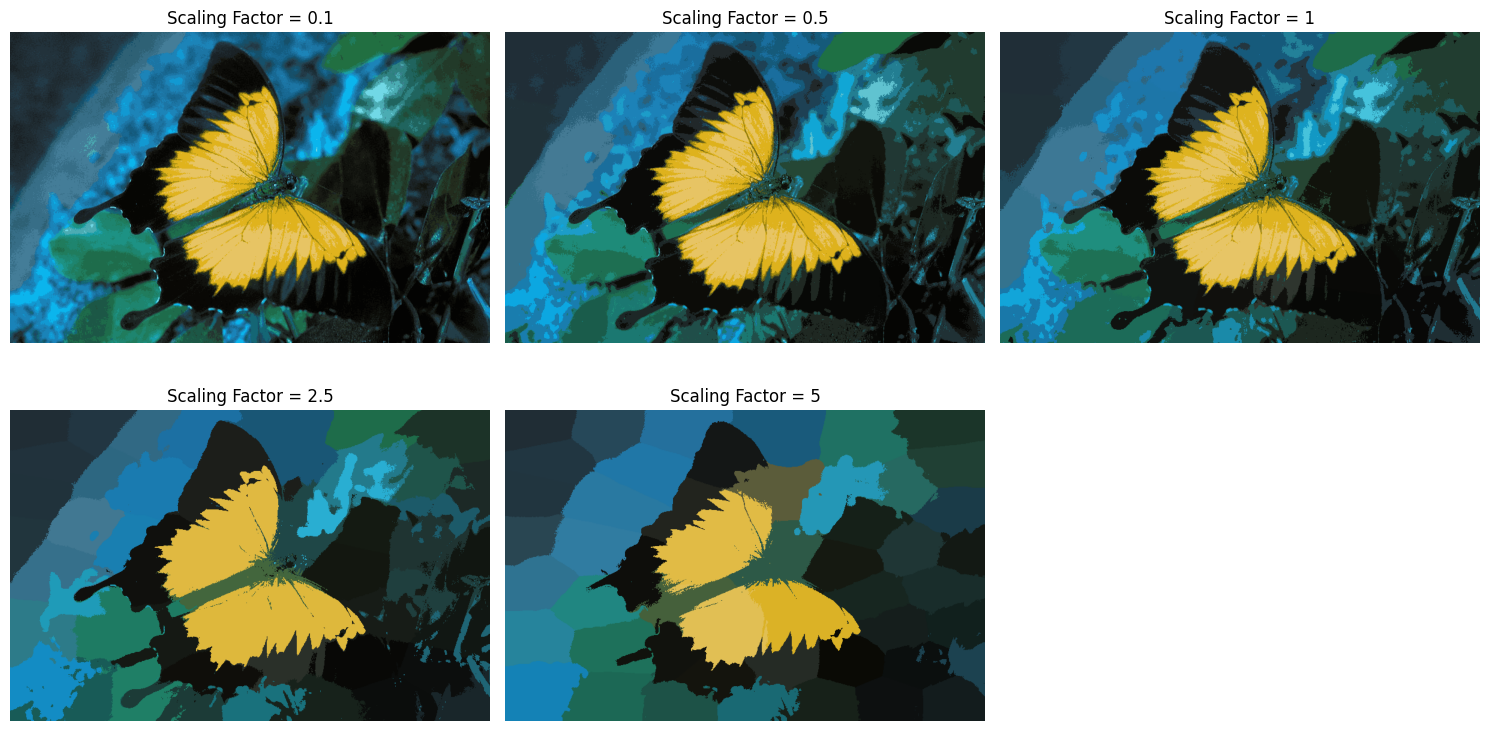

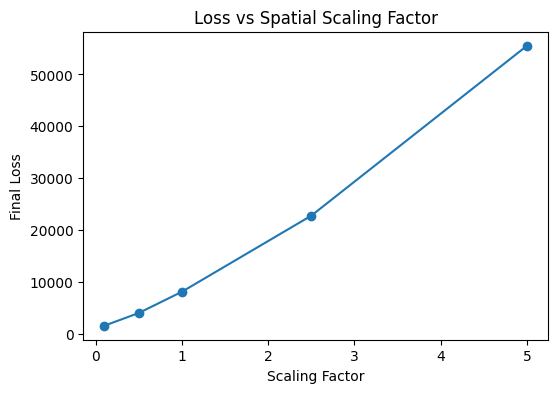

In [57]:
# Visualise your superpixel clustering for different scaling parameters 
scaling = [0.1, 0.5, 1, 2.5, 5]

final_losses = []

plt.figure(figsize=(15,8))

for i, spatial_scale in enumerate(scaling):

    loss, cluster_img, quant_img = kmeans_superpixels(im, iters=15, K=50, plot=False, spatial_scaling=spatial_scale)

    final_losses.append(loss)


    plt.subplot(2,3,i+1)
    plt.imshow(quant_img)
    plt.title(f"Scaling Factor = {spatial_scale}")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))

plt.plot(scaling, final_losses, marker='o')

plt.xlabel("Scaling Factor")
plt.ylabel("Final Loss")
plt.title("Loss vs Spatial Scaling Factor")

plt.show()

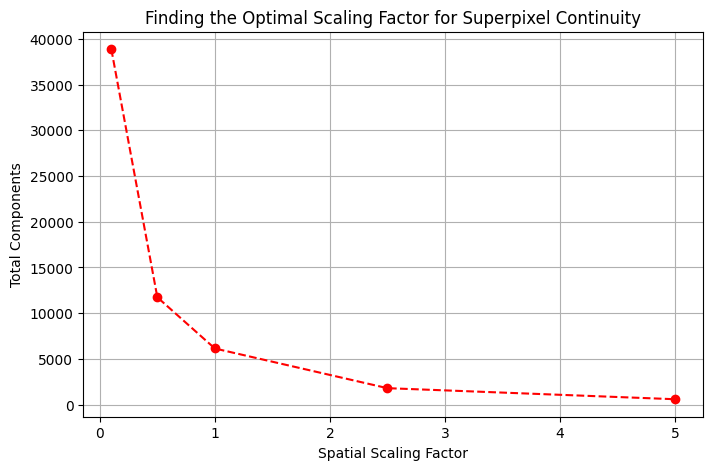

In [58]:
from scipy.ndimage import label

def connectivity_score(cluster_img, K):
    total_components = 0
    
    for k in range(K):
        mask = (cluster_img == k)
        _, num_components = label(mask)
        total_components += num_components
    return total_components

# Testing parameters
scales = [0.1, 0.5, 1, 2.5, 5]
scores = []
test_K = 50

for s in scales:
    
    loss, cluster_img, quant_img = kmeans_superpixels(im, iters=15, K=test_K, spatial_scaling=s)
    
    score = connectivity_score(cluster_img, test_K)
    scores.append(score)


plt.figure(figsize=(8, 5))
plt.plot(scales, scores, marker='o', color='red', linestyle='--')


plt.xlabel("Spatial Scaling Factor")
plt.ylabel("Total Components")
plt.title("Finding the Optimal Scaling Factor for Superpixel Continuity")
plt.grid(True)
plt.show()

A Scaling Factor of 1 seems to offer a balance of continuity and shape fidelity. Higher, details and edges get lost. Lower, there are too many components so there is not enough continuity.

## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


In [ ]:
# Visualise your regions on the original image

## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.
